In [75]:
# !pip3 install lightgbm

In [76]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib 
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from lightgbm import LGBMRegressor, early_stopping, log_evaluation
from scipy import stats

In [77]:
train=pd.read_csv(r"C:\Users\vinod\ML\Redbus Hackathon\train.csv")
df=pd.read_csv(r"C:\Users\vinod\ML\Redbus Hackathon\transactions.csv")
test=pd.read_csv(r"C:\Users\vinod\ML\Redbus Hackathon\test_8gqdJqH.csv")

In [78]:
route_stats = train.groupby(["srcid", "destid"])["final_seatcount"].agg(["mean", "std"]).reset_index()
route_stats.columns = ["srcid", "destid", "route_mean", "route_std"]
train = train.merge(route_stats, on=["srcid", "destid"], how="left")
test = test.merge(route_stats, on=["srcid", "destid"], how="left")

In [79]:
# values1=df['srcid_region'].value_counts()
# values2=df['destid_region'].value_counts()

In [80]:
# labels=values1.index
# plt.figure(figsize=(8,6))
# plt.title("Source Region Value Counts")
# plt.pie(values1,labels=labels,autopct=".%2f")
# plt.show()

In [81]:
# labels2=values2.index
# plt.figure(figsize=(8,6))
# plt.title("Destination Region Value Counts")
# plt.pie(values2,labels=labels2,autopct=".%2f")
# plt.show()

In [82]:
# plt.figure(figsize=(8, 6))
# sns.barplot(x='dbd', y='cumsum_seatcount', data=df)
# plt.title('dbd vs cumsum_seatcount')
# plt.xlabel('dbd')
# plt.ylabel('Final Seatcount')
# plt.grid(True)
# plt.tight_layout()
# plt.show()

In [83]:
# plt.figure(figsize=(8, 6))
# sns.barplot(x='dbd', y='cumsum_searchcount', data=df)
# plt.title('dbd vs cumsum_searchcount')
# plt.xlabel('dbd')
# plt.ylabel('Final Searchcount')
# plt.grid(True)
# plt.tight_layout()
# plt.show()

In [84]:
# from ydata_profiling import ProfileReport
# prof=ProfileReport(df,explorative=True)
# prof.to_file(output_file="EDA_Redbus1.html")

In [85]:
train.head(),train.shape

(          doj  srcid  destid  final_seatcount   route_mean    route_std
 0  2023-03-01     45      46           2838.0  4218.648810  1069.316880
 1  2023-03-01     46      45           2298.0  4044.571429  1103.766561
 2  2023-03-01     45      47           2720.0  4022.431548  1128.414758
 3  2023-03-01     47      45           2580.0  4015.877976  1054.536895
 4  2023-03-01     46       9           4185.0  4954.995536  1507.324675,
 (67200, 6))

In [86]:
test.head(),test.shape

(          route_key         doj  srcid  destid   route_mean    route_std
 0  2025-02-11_46_45  2025-02-11     46      45  4044.571429  1103.766561
 1  2025-01-20_17_23  2025-01-20     17      23  1321.897321   389.919087
 2  2025-01-08_02_14  2025-01-08      2      14  1538.325893   680.785677
 3  2025-01-08_08_47  2025-01-08      8      47  1481.488095   616.389071
 4  2025-01-08_09_46  2025-01-08      9      46  4814.683036  1586.108421,
 (5900, 6))

# daily_seatcount- from doi (30,10)-1

In [87]:
df.head(),df.shape

(          doj         doi  srcid  destid    srcid_region   destid_region  \
 0  2023-03-01  2023-01-30     45      46       Karnataka      Tamil Nadu   
 1  2023-03-01  2023-01-30     46      45      Tamil Nadu       Karnataka   
 2  2023-03-01  2023-01-30     45      47       Karnataka  Andhra Pradesh   
 3  2023-03-01  2023-01-30     47      45  Andhra Pradesh       Karnataka   
 4  2023-03-01  2023-01-30     46       9      Tamil Nadu      Tamil Nadu   
 
   srcid_tier destid_tier  cumsum_seatcount  cumsum_searchcount  dbd  
 0     Tier 1      Tier 1               8.0                76.0   30  
 1     Tier 1      Tier 1               8.0                70.0   30  
 2     Tier 1      Tier 1               4.0               142.0   30  
 3     Tier 1      Tier 1               0.0                68.0   30  
 4     Tier 1       Tier2               9.0               162.0   30  ,
 (2266100, 11))

# New columns

In [88]:
df['route_key'] = df['doj'].astype(str) + '_' + df['srcid'].astype(str) + '_' + df['destid'].astype(str)
train['route_key'] = train['doj'].astype(str) + '_' + train['srcid'].astype(str) + '_' + train['destid'].astype(str)

In [89]:
df= pd.merge(train,df, on=['route_key','srcid','destid','doj'])
df.shape

(2083200, 15)

In [90]:
df["doj"] = pd.to_datetime(df["doj"])
df["doi"] = pd.to_datetime(df["doi"])

df["doj_month"] = df["doj"].dt.month
df["doj_week"] = df["doj"].dt.isocalendar().week.astype(int)
df["doj_day"] = df["doj"].dt.day
df["doj_dayofweek"] = df["doj"].dt.dayofweek
df["is_weekend"] = df["doj_dayofweek"].isin([5, 6]).astype(int)


In [91]:
df.groupby('is_weekend')['final_seatcount'].mean()

is_weekend
0    1904.626396
1    2244.487135
Name: final_seatcount, dtype: float64

In [92]:
df['south_region']=np.where(
    (df['srcid_region'].isin(['Tamil Nadu','Maharshtra and Goa','Andhra Pradesh','Karnataka'])) |(df['destid_region'].isin(['Tamil Nadu','Maharshtra and Goa','Andhra Pradesh','Karnataka'])),1,0)

In [93]:
df['srcid_tier'].value_counts()

srcid_tier
Tier 1    1229088
Tier2      645792
Tier 3     124992
Tier 4      83328
Name: count, dtype: int64

In [94]:
for i in range(1,5):
  if(i==2):
    df['srcid_tier']=df['srcid_tier'].replace(f"Tier{i}",i)
    df['destid_tier']=df['destid_tier'].replace(f"Tier{i}",i)
  else:
    df['srcid_tier']=df['srcid_tier'].replace(f"Tier {i}",i)
    df['destid_tier']=df['destid_tier'].replace(f"Tier {i}",i)

In [95]:
df['focus_city'] = np.where(
    (df['srcid_tier'] > 2) | (df['destid_tier'] > 2),0,1
)
df=df.drop(['srcid_tier','destid_tier'],axis=1)

In [96]:
df['seat_to_search_ratio'] = df['final_seatcount'] / (df['cumsum_searchcount'] + 1e-5)

In [97]:
df['daily_seatcount']=df.groupby('route_key')['cumsum_seatcount'].diff().fillna(0)

In [98]:
df['daily_search_count'] = df.groupby('route_key')['cumsum_searchcount'].diff().fillna(0)

In [99]:
df['dbd_bucket'] = pd.cut(df['dbd'], bins=[0,15, 31], labels=[1,0])

In [100]:
df = df.drop(['doj','srcid_region', 'destid_region','doi'], axis=1)

In [101]:
df.sample(5)

,srcid,destid,final_seatcount,route_mean,route_std,route_key,cumsum_seatcount,cumsum_searchcount,dbd,doj_month,doj_week,doj_day,doj_dayofweek,is_weekend,south_region,focus_city,seat_to_search_ratio,daily_seatcount,daily_search_count,dbd_bucket
802092,45,39,872.0,1634.363095,732.145783,2023-11-14_45_39,588.0,7388.0,1,11,46,14,1,0,1,0,0.118029,172.0,2196.0,1
264391,13,23,1600.0,2154.309524,736.358851,2023-05-25_13_23,12.0,288.0,7,5,21,25,3,0,0,1,5.555555,0.0,24.0,1
1374271,7,36,2036.0,1714.154762,798.949220,2024-05-17_7_36,20.0,344.0,20,5,20,17,4,0,0,1,5.918604,0.0,20.0,0
733271,16,2,845.0,1564.367560,625.747489,2023-10-23_16_2,130.0,4700.0,2,10,43,23,0,0,0,1,0.179787,50.0,2285.0,1
1914331,36,27,916.0,1348.458333,648.674745,2024-11-07_36_27,4.0,5704.0,11,11,45,7,3,0,0,1,0.160589,0.0,540.0,1


In [102]:
# df[df['route_key']=='2023-09-07_2_19']


In [103]:
# plt.figure(figsize=(8, 6))
# sns.barplot(x='date', y='final_seatcount', data=date)
# plt.title('dbd vs cumsum_searchcount')
# plt.xlabel('dbd')
# plt.ylabel('Final Searchcount')
# plt.grid(True)
# plt.tight_layout()
# plt.show()

In [104]:
df=df[df['dbd']==15]

In [105]:
# encoding route_key

In [106]:
combo_map = {k: i for i, k in enumerate(df["route_key"].unique())}
df["route_key"] = df["route_key"].map(combo_map)

In [137]:
combo_map = {k: i for i, k in enumerate(test["route_key"].unique())}
test["route_key"] = test["route_key"].map(combo_map)

In [138]:
test.head()

,route_key,doj,srcid,destid,route_mean,route_std
0,0,2025-02-11,46,45,4044.571429,1103.766561
1,1,2025-01-20,17,23,1321.897321,389.919087
2,2,2025-01-08,2,14,1538.325893,680.785677
3,3,2025-01-08,8,47,1481.488095,616.389071
4,4,2025-01-08,9,46,4814.683036,1586.108421


In [132]:
route_key=test['route_key']

In [113]:
# for column in df.columns:
#     sns.displot(df[column+14])
#     plt.title(column)
#     plt.show()

C:\Users\vinod\anaconda3\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


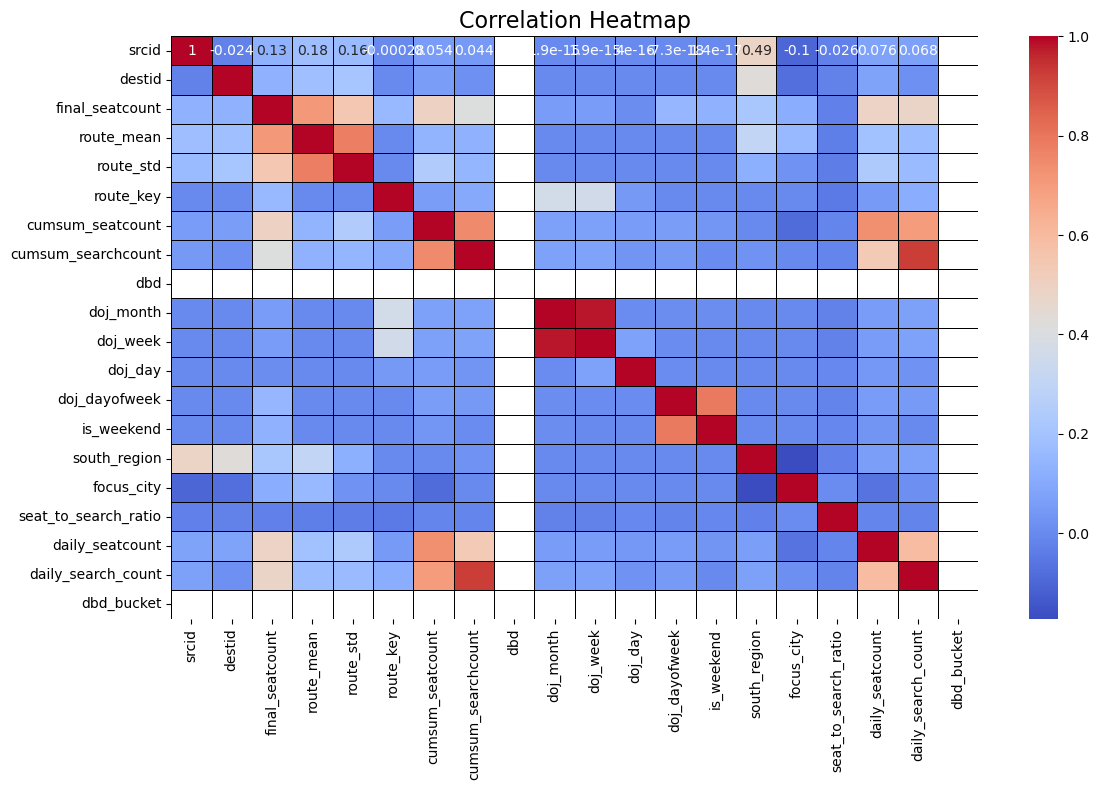

In [114]:
corr = df.corr()

# Set the figure size
plt.figure(figsize=(12, 8))

# Create the heatmap with annotations and color map
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5, linecolor='black')

# Add a title
plt.title("Correlation Heatmap", fontsize=16)

# Show the plot
plt.tight_layout()
plt.show()

In [115]:
df.head()

,srcid,destid,final_seatcount,route_mean,route_std,route_key,cumsum_seatcount,cumsum_searchcount,dbd,doj_month,doj_week,doj_day,doj_dayofweek,is_weekend,south_region,focus_city,seat_to_search_ratio,daily_seatcount,daily_search_count,dbd_bucket
15,45,46,2838.0,4218.648810,1069.316880,0,16.0,480.0,15,3,9,1,2,0,1,1,5.912500,0.0,32.0,1
46,46,45,2298.0,4044.571429,1103.766561,1,34.0,352.0,15,3,9,1,2,0,1,1,6.528409,2.0,28.0,1
77,45,47,2720.0,4022.431548,1128.414758,2,36.0,892.0,15,3,9,1,2,0,1,1,3.049327,6.0,96.0,1
108,47,45,2580.0,4015.877976,1054.536895,3,18.0,1130.0,15,3,9,1,2,0,1,1,2.283186,0.0,50.0,1
139,46,9,4185.0,4954.995536,1507.324675,4,48.0,1023.0,15,3,9,1,2,0,1,1,4.090909,9.0,147.0,1


In [116]:
x=df.drop(['seat_to_search_ratio','dbd','final_seatcount','dbd_bucket','doj_month'],axis=1)
y=df['final_seatcount']
x.shape,y.shape

((67200, 15), (67200,))

In [117]:
x

,srcid,destid,route_mean,route_std,route_key,cumsum_seatcount,cumsum_searchcount,doj_week,doj_day,doj_dayofweek,is_weekend,south_region,focus_city,daily_seatcount,daily_search_count
15,45,46,4218.648810,1069.316880,0,16.0,480.0,9,1,2,0,1,1,0.0,32.0
46,46,45,4044.571429,1103.766561,1,34.0,352.0,9,1,2,0,1,1,2.0,28.0
77,45,47,4022.431548,1128.414758,2,36.0,892.0,9,1,2,0,1,1,6.0,96.0
108,47,45,4015.877976,1054.536895,3,18.0,1130.0,9,1,2,0,1,1,0.0,50.0
139,46,9,4954.995536,1507.324675,4,48.0,1023.0,9,1,2,0,1,1,9.0,147.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2083060,2,24,1304.196429,462.184627,67195,20.0,1300.0,1,31,1,0,0,1,0.0,105.0
2083091,44,45,1292.343750,471.400525,67196,75.0,1220.0,1,31,1,0,1,1,0.0,45.0
2083122,47,10,1203.816964,370.168497,67197,15.0,1560.0,1,31,1,0,1,0,0.0,15.0
2083153,38,36,1214.337798,637.978108,67198,0.0,340.0,1,31,1,0,0,1,0.0,60.0


In [118]:
columns=x.columns
columns

Index(['srcid', 'destid', 'route_mean', 'route_std', 'route_key',
       'cumsum_seatcount', 'cumsum_searchcount', 'doj_week', 'doj_day',
       'doj_dayofweek', 'is_weekend', 'south_region', 'focus_city',
       'daily_seatcount', 'daily_search_count'],
      dtype='object')

In [119]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()

In [120]:
x_scaled=scaler.fit_transform(x)
x_scaled

array([[9.36170213e-01, 9.57446809e-01, 8.47106967e-01, ...,
        1.00000000e+00, 0.00000000e+00, 1.14917762e-03],
       [9.57446809e-01, 9.36170213e-01, 8.10962013e-01, ...,
        1.00000000e+00, 7.46268657e-03, 1.00553042e-03],
       [9.36170213e-01, 9.78723404e-01, 8.06364948e-01, ...,
        1.00000000e+00, 2.23880597e-02, 3.44753286e-03],
       ...,
       [9.78723404e-01, 1.91489362e-01, 2.21115476e-01, ...,
        0.00000000e+00, 0.00000000e+00, 5.38677009e-04],
       [7.87234043e-01, 7.44680851e-01, 2.23299993e-01, ...,
        1.00000000e+00, 0.00000000e+00, 2.15470804e-03],
       [3.82978723e-01, 6.17021277e-01, 2.81619188e-01, ...,
        1.00000000e+00, 1.86567164e-02, 4.66853408e-03]])

In [121]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_scaled,y,random_state=42,test_size=0.2)

In [122]:
x_train

array([[0.95744681, 0.93617021, 0.81096201, ..., 1.        , 0.00746269,
        0.00495583],
       [0.10638298, 0.9787234 , 0.26904199, ..., 0.        , 0.        ,
        0.        ],
       [0.0212766 , 0.38297872, 0.38573291, ..., 1.        , 0.05597015,
        0.00251383],
       ...,
       [0.95744681, 0.68085106, 0.25997177, ..., 0.        , 0.        ,
        0.00377074],
       [0.0212766 , 0.38297872, 0.38573291, ..., 1.        , 0.03731343,
        0.00215471],
       [0.0212766 , 0.4893617 , 0.24195799, ..., 1.        , 0.        ,
        0.00107735]])

In [123]:
train.head()

,doj,srcid,destid,final_seatcount,route_mean,route_std,route_key
0,2023-03-01,45,46,2838.0,4218.648810,1069.316880,2023-03-01_45_46
1,2023-03-01,46,45,2298.0,4044.571429,1103.766561,2023-03-01_46_45
2,2023-03-01,45,47,2720.0,4022.431548,1128.414758,2023-03-01_45_47
3,2023-03-01,47,45,2580.0,4015.877976,1054.536895,2023-03-01_47_45
4,2023-03-01,46,9,4185.0,4954.995536,1507.324675,2023-03-01_46_9


In [124]:
def train_model(X_train, y_train, X_val, y_val):
    """Train LightGBM model with early stopping"""
    print("\nTraining model...")
    
    model = LGBMRegressor(
        learning_rate=0.05,
        max_depth=20,
        num_leaves=44,
        feature_fraction=0.7,
        bagging_fraction=0.8,
        bagging_freq=5,
        n_estimators=1000,
        random_state=13,
        force_col_wise=True  # Suppress warning
    )
    
    model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[
            early_stopping(stopping_rounds=100),
            log_evaluation(period=100)
        ]
    )
    
    return model

In [125]:
def evaluate_model(model, X_val, y_val):
    """Evaluate model performance and generate diagnostics"""
    print("\nEvaluating model...")
    
    # Generate predictions
    val_preds = model.predict(X_val)
    
    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_val, val_preds))
    mae = mean_absolute_error(y_val, val_preds)
    r2 = r2_score(y_val, val_preds)
    
    print(f"\nValidation Metrics:")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R²: {r2:.4f}")
    
    # Plot feature importance
    plt.figure(figsize=(10, 8))
    feat_imp = pd.Series(model.feature_importances_, index=columns)
    feat_imp.nlargest(15).sort_values().plot(kind='barh')
    plt.title('Top 15 Feature Importances')
    plt.tight_layout()
    plt.savefig('feature_importance.png')
    plt.show()
    
    # Plot actual vs predicted
    plt.figure(figsize=(10, 6))
    sns.regplot(x=y_val, y=val_preds, scatter_kws={'alpha':0.3})
    plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'k--')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title('Actual vs Predicted Values')
    plt.tight_layout()
    plt.savefig('actual_vs_predicted.png')
    plt.show()
    
    # Plot error distribution
    errors = y_val - val_preds
    plt.figure(figsize=(10, 6))
    sns.histplot(errors, kde=True)
    plt.xlabel('Prediction Error')
    plt.title('Error Distribution')
    plt.tight_layout()
    plt.savefig('error_distribution.png')
    plt.show()

In [126]:
model=train_model(x_train,y_train,x_test,y_test)


Training model...
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Info] Total Bins 1499
[LightGBM] [Info] Number of data points in the train set: 53760, number of used features: 15
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fra


Evaluating model...
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5

Validation Metrics:
RMSE: 326.8678
MAE: 234.0006
R²: 0.9258


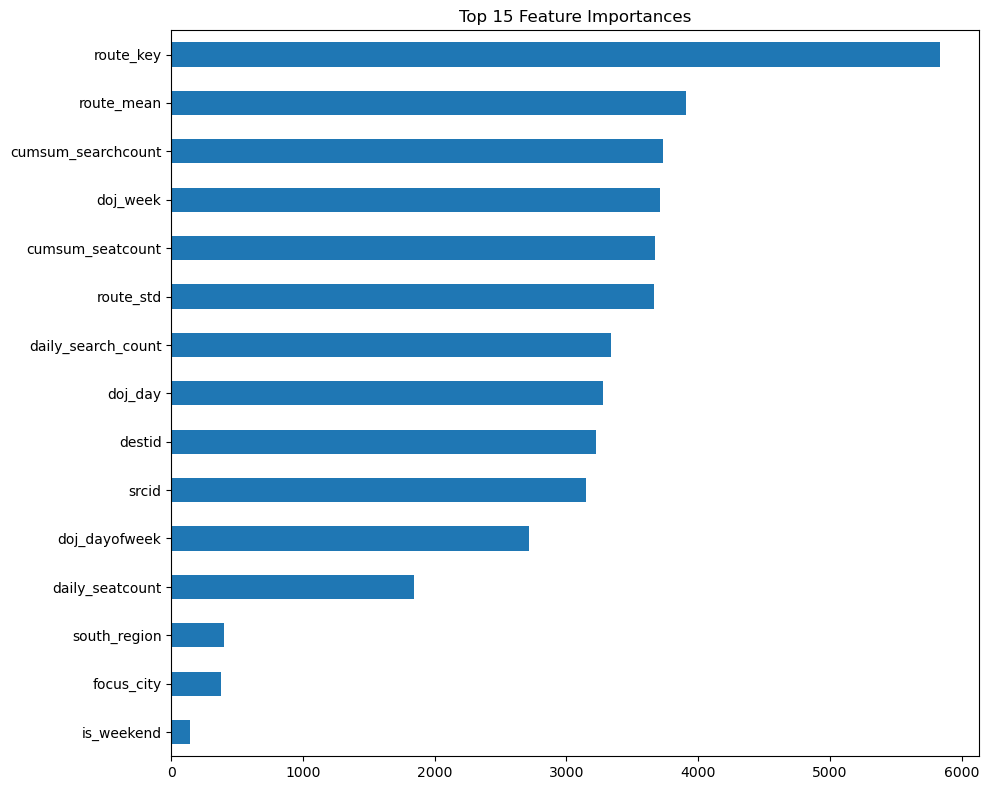

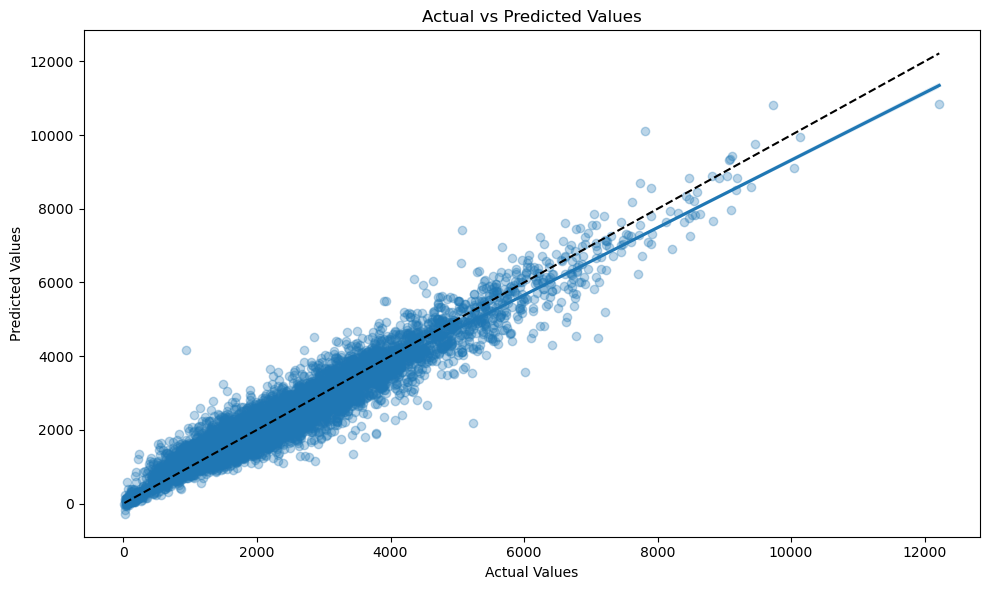

C:\Users\vinod\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


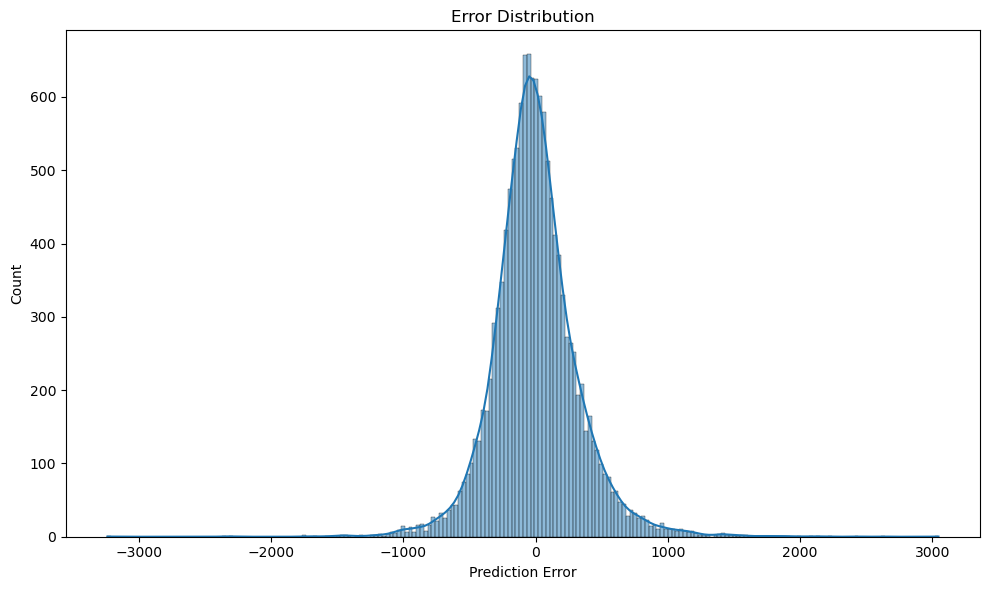

In [127]:
evaluate_model(model,x_test,y_test)

In [140]:
y_pred=model.predict(route_key)
y_pred

ValueError: Expected 2D array, got 1D array instead:
array=[   0    1    2 ... 5897 5898 5899].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

In [129]:
df.head()

,srcid,destid,final_seatcount,route_mean,route_std,route_key,cumsum_seatcount,cumsum_searchcount,dbd,doj_month,doj_week,doj_day,doj_dayofweek,is_weekend,south_region,focus_city,seat_to_search_ratio,daily_seatcount,daily_search_count,dbd_bucket
15,45,46,2838.0,4218.648810,1069.316880,0,16.0,480.0,15,3,9,1,2,0,1,1,5.912500,0.0,32.0,1
46,46,45,2298.0,4044.571429,1103.766561,1,34.0,352.0,15,3,9,1,2,0,1,1,6.528409,2.0,28.0,1
77,45,47,2720.0,4022.431548,1128.414758,2,36.0,892.0,15,3,9,1,2,0,1,1,3.049327,6.0,96.0,1
108,47,45,2580.0,4015.877976,1054.536895,3,18.0,1130.0,15,3,9,1,2,0,1,1,2.283186,0.0,50.0,1
139,46,9,4185.0,4954.995536,1507.324675,4,48.0,1023.0,15,3,9,1,2,0,1,1,4.090909,9.0,147.0,1


In [ ]:
def prepare_test_data(X_test, X_train, encoders):
    """Prepare test data for prediction"""
    print("\nPreparing test data...")
    
    X_test = X_test.fillna(0)
    
    # Encode categoricals
    for col in X_test.select_dtypes(include=["object"]).columns:
        if col in encoders:
            le = encoders[col]
            X_test[col] = le.transform(X_test[col].astype(str))
        else:
            X_test[col] = LabelEncoder().fit_transform(X_test[col].astype(str))
    
    # Align columns
    missing_cols = set(X_train.columns) - set(X_test.columns)
    for col in missing_cols:
        X_test[col] = 0
    X_test = X_test[X_train.columns]
    
    return X_test

In [130]:
# def prepare_test_data(X_test, X_train, encoders):
#     """Prepare test data for prediction"""
#     print("\nPreparing test data...")
    
#     X_test = X_test.fillna(0)
    
#     # Encode categoricals
#     for col in X_test.select_dtypes(include=["object"]).columns:
#         if col in encoders:
#             le = encoders[col]
#             X_test[col] = le.transform(X_test[col].astype(str))
#         else:
#             X_test[col] = LabelEncoder().fit_transform(X_test[col].astype(str))
    
#     # Align columns
#     missing_cols = set(X_train.columns) - set(X_test.columns)
#     for col in missing_cols:
#         X_test[col] = 0
#     X_test = X_test[X_train.columns]
    
#     return X_test

In [136]:
test.head()

,route_key,doj,srcid,destid,route_mean,route_std
0,0,2025-02-11,46,45,4044.571429,1103.766561
1,1,2025-01-20,17,23,1321.897321,389.919087
2,2,2025-01-08,2,14,1538.325893,680.785677
3,3,2025-01-08,8,47,1481.488095,616.389071
4,4,2025-01-08,9,46,4814.683036,1586.108421


In [135]:
route_key=test['route_key']

0          0
1          1
2          2
3          3
4          4
        ... 
5895    5895
5896    5896
5897    5897
5898    5898
5899    5899
Name: route_key, Length: 5900, dtype: int64

In [134]:
output_df = pd.DataFrame({
    'route_key': route_key,
    'predicted_final_seatcount': y_pred
})

# Save to CSV
output_df.to_csv('predictions.csv', index=False)

ValueError: array length 13440 does not match index length 5900